# Sampling distributions, standard errors and the bootstrap — toy examples

Everything here is simulated so you can *see* the definitions, then re-checked on the real
hourly consumption series where autocorrelation changes the answers.

**What's in here**
- population vs sample; the sampling distribution of the mean
- standard error = std of the sampling distribution; σ/√n and where it fails (Cauchy)
- SE of a proportion, of a difference of means, of a regression slope
- confidence intervals and what "95%" actually means (coverage by simulation)
- the bootstrap: mean, median, ratio, correlation, regression coefficient; `scipy.stats.bootstrap`
- when the bootstrap fails
- autocorrelation: naive vs block bootstrap vs effective sample size on real data
- interview checks: SE of a Sharpe ratio; "is a mean error of 53 MWh bias?"
- quick-reference table of SE formulas

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

## 1. Population vs sample

A *population* is the thing we want to know about; a *sample* is what we have. Here the
population is the annual consumption (kWh) of 100,000 customers, lognormal so it is skewed.
One sample of n = 50 gives a mean and std that are *estimates* — they would be different
with a different sample.

In [2]:
N_POP = 100_000
population = rng.lognormal(mean=np.log(3200), sigma=0.45, size=N_POP)   # annual kWh per customer
mu, sigma = population.mean(), population.std()

sample = rng.choice(population, size=50, replace=False)
pd.DataFrame({
    "population": [mu, sigma, np.median(population), stats.skew(population)],
    "sample (n=50)": [sample.mean(), sample.std(ddof=1), np.median(sample), stats.skew(sample)],
}, index=["mean", "std", "median", "skew"]).round(1)

,population,sample (n=50)
mean,3537.4,3449.1
std,1688.7,1156.4
median,3187.1,3340.2
skew,1.6,0.6


## 2. The sampling distribution of the mean

Repeat the experiment: draw 10,000 samples of size n, take the mean of each. The spread of
those 10,000 means is the **standard error**. The Central Limit Theorem says it is
≈ σ/√n and the shape becomes normal even though the population is skewed.

In [3]:
B = 10_000
rows = []
for n in [10, 50, 200, 1000]:
    means = rng.choice(population, size=(B, n)).mean(axis=1)
    rows.append({"n": n, "mean of means": means.mean(), "std of means (SE, simulated)": means.std(),
                 "sigma/sqrt(n)": sigma / np.sqrt(n), "skew of means": stats.skew(means)})
pd.DataFrame(rows).round(2)

,n,mean of means,"std of means (SE, simulated)",sigma/sqrt(n),skew of means
0,10,3536.95,535.00,534.01,0.47
1,50,3537.98,237.62,238.82,0.19
2,200,3535.38,119.82,119.41,0.10
3,1000,3536.81,53.63,53.40,0.04


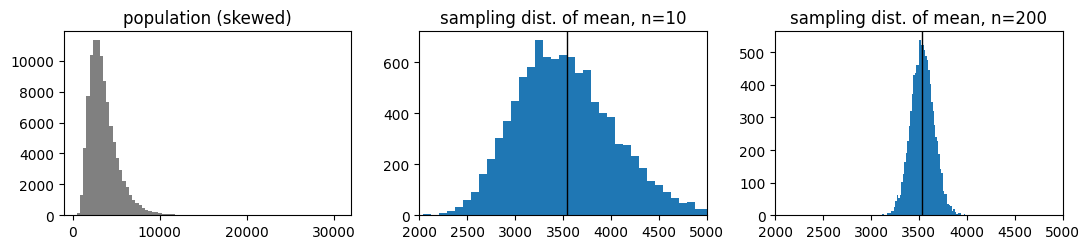

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.6))
axes[0].hist(population, bins=80, color="grey"); axes[0].set_title("population (skewed)")
for ax, n in zip(axes[1:], [10, 200]):
    means = rng.choice(population, size=(B, n)).mean(axis=1)
    ax.hist(means, bins=60, color="tab:blue"); ax.axvline(mu, color="k", lw=1)
    ax.set_title(f"sampling dist. of mean, n={n}"); ax.set_xlim(2000, 5000)
plt.tight_layout()

**Pitfall:** the CLT needs a finite variance. For a Cauchy (heavy-tailed) population the
sample mean does *not* settle down as n grows: its distribution is the same Cauchy at every n.
Fat-tailed P&L or price-spike data can behave like this in practice — then use the median or
trimmed mean and check the tails.

In [5]:
rows = []
for n in [10, 100, 1000, 10_000]:
    m = rng.standard_cauchy(size=(2000, n)).mean(axis=1)
    med = np.median(rng.standard_cauchy(size=(2000, n)), axis=1)
    rows.append({"n": n, "IQR of sample MEANS": np.subtract(*np.percentile(m, [75, 25])),
                 "IQR of sample MEDIANS": np.subtract(*np.percentile(med, [75, 25]))})
pd.DataFrame(rows).round(3)

,n,IQR of sample MEANS,IQR of sample MEDIANS
0,10,2.010,0.648
1,100,2.023,0.210
2,1000,2.152,0.067
3,10000,1.919,0.020


## 3. Standard error vs standard deviation

One line: **SD describes the spread of the data; SE describes the uncertainty of an estimate.**
SD does not shrink with n; SE shrinks as 1/√n.

In [6]:
rows = []
for n in [10, 100, 1000, 10_000]:
    s = rng.choice(population, size=n)
    rows.append({"n": n, "sample SD": s.std(ddof=1), "SE of mean = SD/sqrt(n)": s.std(ddof=1) / np.sqrt(n)})
pd.DataFrame(rows).round(1)

,n,sample SD,SE of mean = SD/sqrt(n)
0,10,2411.1,762.5
1,100,1792.9,179.3
2,1000,1758.2,55.6
3,10000,1662.3,16.6


### SE of a proportion, of a difference of means, of a regression slope

Three formulas you should be able to write down, each checked against simulation.

In [7]:
# proportion: p_hat ~ SE sqrt(p(1-p)/n)
p, n = 0.12, 400                       # 12% of meters have solar, sample of 400
sim = rng.binomial(n, p, size=20_000) / n
print(f"proportion   simulated SE {sim.std():.4f}   formula {np.sqrt(p*(1-p)/n):.4f}")

# difference of two means: SE sqrt(s1^2/n1 + s2^2/n2)
n1, n2 = 60, 40
a = rng.normal(30_000, 4_000, size=(20_000, n1)); b = rng.normal(28_000, 3_000, size=(20_000, n2))
diff = a.mean(1) - b.mean(1)
print(f"diff of means simulated SE {diff.std():.1f}   formula {np.sqrt(4000**2/n1 + 3000**2/n2):.1f}")

proportion   simulated SE 0.0163   formula 0.0162
diff of means simulated SE 703.8   formula 701.2


In [8]:
# regression slope: SE = sigma_resid / sqrt(sum((x - xbar)^2))
n, beta, sd_e = 80, -300.0, 1500.0
x = rng.uniform(-5, 20, n)                          # temperature
slopes = []
for _ in range(5000):
    y = 30_000 + beta * x + rng.normal(0, sd_e, n)
    slopes.append(np.polyfit(x, y, 1)[0])
slopes = np.array(slopes)

y = 30_000 + beta * x + rng.normal(0, sd_e, n)      # one dataset for the analytical / scipy SE
lr = stats.linregress(x, y)
resid = y - (lr.intercept + lr.slope * x)
se_formula = np.sqrt((resid**2).sum() / (n - 2)) / np.sqrt(((x - x.mean())**2).sum())
print(f"slope SE   simulated {slopes.std():.2f}   formula {se_formula:.2f}   linregress.stderr {lr.stderr:.2f}")

slope SE   simulated 22.68   formula 23.84   linregress.stderr 23.84


## 4. Confidence intervals and what 95% means

A 95% CI is a *procedure*: if you repeat the experiment many times, 95% of the intervals
you build will contain the true value. It is not "there is a 95% chance μ is in this
interval" — μ is fixed, the interval is what varies.

**Pitfall:** with small n and unknown σ use the t distribution, otherwise coverage falls
short of 95%.

In [9]:
def coverage(n, B=5000, use_t=False):
    s = rng.choice(population, size=(B, n))
    m, se = s.mean(1), s.std(1, ddof=1) / np.sqrt(n)
    z = stats.t.ppf(0.975, n - 1) if use_t else 1.96
    return ((m - z*se <= mu) & (mu <= m + z*se)).mean()

pd.DataFrame({
    "n": [5, 10, 30, 200],
    "coverage z=1.96": [coverage(n) for n in [5, 10, 30, 200]],
    "coverage t-based": [coverage(n, use_t=True) for n in [5, 10, 30, 200]],
}).round(3)

,n,coverage z=1.96,coverage t-based
0,5,0.846,0.921
1,10,0.894,0.928
2,30,0.927,0.941
3,200,0.947,0.941


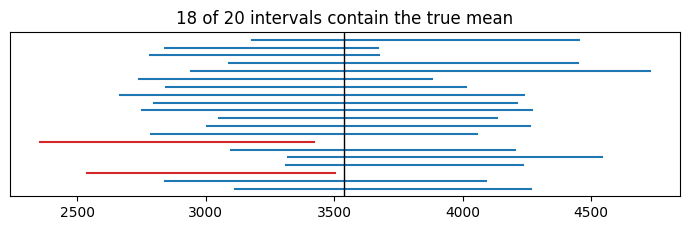

In [10]:
# 20 intervals from 20 samples of n=30: some miss, and you never know which
s = rng.choice(population, size=(20, 30)); m = s.mean(1); se = s.std(1, ddof=1)/np.sqrt(30)
lo, hi = m - 2.045*se, m + 2.045*se
fig, ax = plt.subplots(figsize=(7, 2.4))
for i in range(20):
    ax.plot([lo[i], hi[i]], [i, i], color="tab:red" if (lo[i] > mu or hi[i] < mu) else "tab:blue")
ax.axvline(mu, color="k", lw=1); ax.set_yticks([]); ax.set_title(f"{((lo <= mu) & (mu <= hi)).sum()} of 20 intervals contain the true mean")
plt.tight_layout()

## 5. The bootstrap

When there is no formula (median, ratio, correlation, a coefficient in a weird model) resample
the *sample* with replacement B times, recompute the statistic each time, and read the SE and
percentile CI off the bootstrap distribution. It works because the sample is the best estimate
of the population.

In [11]:
sample = rng.choice(population, size=200, replace=False)
B = 2000
idx = rng.integers(0, len(sample), size=(B, len(sample)))       # B resamples at once
boot = sample[idx]

rows = []
for name, fn, analytic in [
    ("mean", lambda a: a.mean(axis=1), sample.std(ddof=1)/np.sqrt(len(sample))),
    ("median", lambda a: np.median(a, axis=1), np.nan),
    ("p90 / median ratio", lambda a: np.percentile(a, 90, axis=1)/np.median(a, axis=1), np.nan),
]:
    d = fn(boot)
    rows.append({"statistic": name, "estimate": fn(sample[None, :])[0], "boot SE": d.std(ddof=1),
                 "analytic SE": analytic, "CI 2.5%": np.percentile(d, 2.5), "CI 97.5%": np.percentile(d, 97.5)})
pd.DataFrame(rows).round(2)

,statistic,estimate,boot SE,analytic SE,CI 2.5%,CI 97.5%
0,mean,3746.01,132.11,135.35,3496.90,4003.44
1,median,3438.74,182.58,NaN,3160.56,3780.10
2,p90 / median ratio,1.86,0.12,NaN,1.56,2.03


In [12]:
# correlation and a regression coefficient: resample ROWS (pairs), never x and y separately
n = 150
x = rng.normal(10, 6, n); y = 30_000 - 300*x + rng.normal(0, 1500, n)
idx = rng.integers(0, n, size=(B, n))
corr_b = np.array([np.corrcoef(x[i], y[i])[0, 1] for i in idx])
slope_b = np.array([np.polyfit(x[i], y[i], 1)[0] for i in idx])
lr = stats.linregress(x, y)
print(f"corr  {lr.rvalue:.3f}   boot SE {corr_b.std():.3f}   CI [{np.percentile(corr_b, 2.5):.3f}, {np.percentile(corr_b, 97.5):.3f}]")
print(f"slope {lr.slope:.1f}   boot SE {slope_b.std():.1f}   analytic SE {lr.stderr:.1f}")

corr  -0.763   boot SE 0.036   CI [-0.827, -0.693]
slope -312.5   boot SE 22.0   analytic SE 21.8


`scipy.stats.bootstrap` does the same with a few extra options (BCa intervals, paired
resampling). Pass the data as a tuple of arrays and a statistic that accepts `axis`.

In [13]:
res = stats.bootstrap((sample,), np.mean, n_resamples=2000, confidence_level=0.95,
                      method="percentile", random_state=1)
print("percentile CI:", np.round(res.confidence_interval, 1), " SE:", round(res.standard_error, 2))
res_bca = stats.bootstrap((sample,), np.median, n_resamples=2000, method="BCa", random_state=1)
print("BCa CI for the median:", np.round(res_bca.confidence_interval, 1))
def slope_stat(a, b, axis=-1):
    a_c = a - a.mean(axis=axis, keepdims=True); b_c = b - b.mean(axis=axis, keepdims=True)
    return (a_c * b_c).sum(axis=axis) / (a_c**2).sum(axis=axis)

res_pair = stats.bootstrap((x, y), slope_stat, paired=True, vectorized=True,
                           n_resamples=2000, random_state=1)
print("paired bootstrap CI for the slope:", np.round(res_pair.confidence_interval, 1))

percentile CI: [3496.7 4016.3]  SE: 134.63
BCa CI for the median: [3160.6 3780. ]
paired bootstrap CI for the slope: [-355.5 -267.4]


**Pitfall:** the bootstrap fails for statistics that depend on a few extreme points (max,
a 99.9th percentile, tiny n): the resampled max can never exceed the observed max, so the CI
is biased and too narrow.

In [14]:
true_p999 = np.percentile(population, 99.9)
rows = []
for n in [30, 200, 5000]:
    s = rng.choice(population, size=n); idx = rng.integers(0, n, size=(1000, n))
    d = np.percentile(s[idx], 99.9, axis=1); mx = s[idx].max(axis=1)
    rows.append({"n": n, "true p99.9": true_p999, "boot CI lo": np.percentile(d, 2.5), "boot CI hi": np.percentile(d, 97.5),
                 "covers?": np.percentile(d, 2.5) <= true_p999 <= np.percentile(d, 97.5), "boot max never exceeds sample max": mx.max() == s.max()})
pd.DataFrame(rows).round(0)

,n,true p99.9,boot CI lo,boot CI hi,covers?,boot max never exceeds sample max
0,30,12893.0,5369.0,6767.0,False,True
1,200,12893.0,7719.0,10796.0,False,True
2,5000,12893.0,11397.0,13667.0,True,True


### The bootstrap has its own Monte Carlo noise

B = 100 resamples gives a noisy SE; the SE-of-the-SE falls like 1/√B. Use B ≥ 1000 for SEs
and ≥ 2000-5000 for percentile CIs.

In [15]:
rows = []
for Bsz in [50, 200, 1000, 5000]:
    ses = [sample[rng.integers(0, len(sample), size=(Bsz, len(sample)))].mean(1).std() for _ in range(30)]
    rows.append({"B": Bsz, "boot SE (mean over 30 runs)": np.mean(ses), "spread of boot SE across runs": np.std(ses)})
pd.DataFrame(rows).round(2)

,B,boot SE (mean over 30 runs),spread of boot SE across runs
0,50,131.59,12.40
1,200,133.43,7.03
2,1000,134.78,2.85
3,5000,135.28,1.32


## 6. Autocorrelation breaks the iid bootstrap (real data)

Hourly consumption has lag-1 autocorrelation near 1. Resampling individual hours treats
17,520 hours as 17,520 independent draws. They are not: the effective sample size is
n_eff ≈ n (1−ρ)/(1+ρ), and for long memory even that is optimistic. A **block bootstrap**
resamples contiguous blocks (days or weeks) to keep the dependence.

**Interview check:** "how many independent observations do you actually have?"

In [16]:
df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"])
c = df["consumption_mwh"].to_numpy(); n = len(c)
rho1 = np.corrcoef(c[:-1], c[1:])[0, 1]
n_eff = n * (1 - rho1) / (1 + rho1)
print(f"n = {n}, lag-1 autocorr = {rho1:.3f}, n_eff ≈ {n_eff:.0f}")

def block_bootstrap_means(x, block, B=2000):
    nb = int(np.ceil(len(x) / block))
    starts = rng.integers(0, len(x) - block + 1, size=(B, nb))
    blocks = x[starts[:, :, None] + np.arange(block)]            # (B, nb, block)
    return blocks.reshape(B, -1)[:, :len(x)].mean(axis=1)

naive = c[rng.integers(0, n, size=(2000, n))].mean(1)
rows = [{"method": "naive iid bootstrap", "SE of mean": naive.std()},
        {"method": "sigma/sqrt(n_eff)", "SE of mean": c.std(ddof=1)/np.sqrt(n_eff)}]
for blk in [24, 168, 720]:
    rows.append({"method": f"block bootstrap, block={blk}h", "SE of mean": block_bootstrap_means(c, blk).std()})
pd.DataFrame(rows).round(1)

n = 17520, lag-1 autocorr = 0.935, n_eff ≈ 588


,method,SE of mean
0,naive iid bootstrap,30.6
1,sigma/sqrt(n_eff),173.4
2,"block bootstrap, block=24h",80.0
3,"block bootstrap, block=168h",191.5
4,"block bootstrap, block=720h",362.4


The naive SE is an order of magnitude too small. Notice the block SE keeps growing as the
block gets longer: seasonality and the slow trend mean even monthly blocks are not
independent. With two years of data you have very few truly independent "seasons".

## 7. Interview checks

**"Your backtest Sharpe is 1.2 over 3 years of daily returns. What is its standard error?"**
For iid returns SE(SR) ≈ √((1 + SR²/2)/n) with SR in per-period units. Annualising
multiplies both SR and SE by √252.

In [17]:
n_days, sr_annual = 3*252, 1.2
sr_daily = sr_annual / np.sqrt(252)
se_daily = np.sqrt((1 + sr_daily**2/2) / n_days)
print(f"daily SR {sr_daily:.4f}, SE {se_daily:.4f}  ->  annual SR {sr_annual:.2f} ± {se_daily*np.sqrt(252):.2f}")

# check by simulation: daily returns with that true Sharpe
r = rng.normal(sr_daily*0.01, 0.01, size=(5000, n_days))
sr_sim = r.mean(1)/r.std(1, ddof=1)*np.sqrt(252)
print(f"simulated annual SR mean {sr_sim.mean():.2f}, SE {sr_sim.std():.2f}   (t-stat of the 1.2 Sharpe ≈ {sr_annual/(se_daily*np.sqrt(252)):.1f})")

daily SR 0.0756, SE 0.0364  ->  annual SR 1.20 ± 0.58
simulated annual SR mean 1.22, SE 0.58   (t-stat of the 1.2 Sharpe ≈ 2.1)


**"The mean forecast error on the test set is 80 MWh. Is the model biased?"**
The naive answer divides by SD/√n. Forecast errors are autocorrelated, so the iid t-stat is
too confident. Two corrections: the AR(1) effective-sample-size formula, and a block bootstrap.
They can disagree with each other — the n_eff formula assumes AR(1) decay, while these errors
mean-revert within a day, and week-long blocks each contain a full weekly error cycle, which
lowers the between-block variance — so when it matters, show several and say why they differ.

In [18]:
# lag-24 persistence errors on the last 3500 hours, shifted so the mean error is exactly 80 MWh
y = c[24:]; yhat = c[:-24]
err = (y - yhat)[-3500:]
err = err - err.mean() + 80.0
rho = np.corrcoef(err[:-1], err[1:])[0, 1]
ne = len(err) * (1 - rho) / (1 + rho)
t_iid = err.mean() / (err.std(ddof=1)/np.sqrt(len(err)))
t_eff = err.mean() / (err.std(ddof=1)/np.sqrt(ne))
t_blk24 = err.mean() / block_bootstrap_means(err, 24).std()
t_blk168 = err.mean() / block_bootstrap_means(err, 168).std()
print(f"mean error {err.mean():.1f} MWh | lag-1 autocorr {rho:.2f} | n {len(err)} n_eff {ne:.0f}")
print(f"t-stat: iid {t_iid:.1f}   n_eff-adjusted {t_eff:.1f}   block bootstrap 24h {t_blk24:.1f}   168h {t_blk168:.1f}")

mean error 80.0 MWh | lag-1 autocorr 0.88 | n 3500 n_eff 223
t-stat: iid 2.9   n_eff-adjusted 0.7   block bootstrap 24h 0.9   168h 2.6


## Quick reference — standard errors

| Estimate | SE (iid) | Notes |
|---|---|---|
| mean | s/√n | s = sample SD (ddof=1) |
| proportion p̂ | √(p̂(1−p̂)/n) | Wilson interval better for small n or p near 0/1 |
| difference of means | √(s₁²/n₁ + s₂²/n₂) | Welch; paired data → SE of the differences |
| OLS slope | σ̂ / √Σ(x−x̄)² | σ̂² = SSE/(n−2); inflated by autocorrelated residuals |
| correlation r | ≈ (1−r²)/√(n−2) | or Fisher z: SE = 1/√(n−3) |
| Sharpe (per period) | √((1+SR²/2)/n) | ×√252 to annualise both |
| median, ratio, anything | bootstrap | resample rows; blocks if dependent |
| any of the above with dependence | replace n by n_eff ≈ n(1−ρ)/(1+ρ) | or block bootstrap / Newey-West |

- SD describes data spread; SE describes estimator uncertainty and shrinks as 1/√n.
- A 95% CI is a property of the procedure, not of one interval.
- Bootstrap: B ≥ 2000, resample pairs jointly, avoid extremes, block for time series.
- Always ask "how many independent observations do I really have?"